# 🏦 Bank Account Fraud Detection — BAF Suite (NeurIPS 2022)

**Notebook 1: Exploratory Data Analysis**

| | |
|---|---|
| **Author** | Udit Jadli |
| **Dataset** | [Bank Account Fraud Suite (NeurIPS 2022)](https://www.kaggle.com/datasets/sgpjesus/bank-account-fraud-dataset-neurips-2022) — Feedzai |
| **Objective** | Understand the data before modelling: quantify the class imbalance, uncover hidden missing values, and identify the feature groups needed for fairness analysis. |

---

This notebook does **no modelling and no resampling** — it is a disciplined first look at the data. The central challenge of fraud detection is *extreme class imbalance*: fraud is rare, so accuracy is meaningless and everything downstream depends on understanding that imbalance first.

---

## Section 1 — Import Libraries

Standard data-analysis stack: **pandas** and **NumPy** for data handling, **Matplotlib** and **seaborn** for visualisation. No modelling libraries yet — those come in later notebooks.

In [22]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings - show all columns so nothing is hidden when we preview
pd.set_option('display.max_columns', None)

# Set a clean default style for all our charts
sns.set_style('whitegrid')

print("Libraries imported successfully.")

Libraries imported successfully.


---

## Section 2 — Load Data

The BAF suite ships six files (Base + Variant I–V). We work with **Base.csv** — the primary variant, ~1 million account applications. The other variants are held back for the fairness comparison in a later notebook.


In [23]:
# The notebook lives in notebooks/, so we step up one level (..) to reach data/
# Base.csv is the primary BAF variant with ~1 million rows
df = pd.read_csv('../data/Base.csv')

# Confirm the data loaded by checking its size
# .shape returns (rows, columns)
print("Dataset loaded successfully.")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully.
Rows: 1000000
Columns: 32


---

## Section 3 — Data Exploration

A first structured look at the data: preview the rows, inspect data types, review summary statistics, and run an initial missing-value and duplicate check. This tells us what we're working with before we judge data quality.

### 3.1 Preview First 5 Rows

`head()` shows the top rows so we can eyeball the columns and the kind of values each holds.

In [24]:
# head() shows the top 5 rows so we can see the columns and example values
df.head()

,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,payment_type,zip_count_4w,velocity_6h,velocity_24h,velocity_4w,bank_branch_count_8w,date_of_birth_distinct_emails_4w,employment_status,credit_risk_score,email_is_free,housing_status,phone_home_valid,phone_mobile_valid,bank_months_count,has_other_cards,proposed_credit_limit,foreign_request,source,session_length_in_minutes,device_os,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
0,0,0.3,0.986506,-1,25,40,0.006735,102.453711,AA,1059,13096.035018,7850.955007,6742.080561,5,5,CB,163,1,BC,0,1,9,0,1500.0,0,INTERNET,16.224843,linux,1,1,0,0
1,0,0.8,0.617426,-1,89,20,0.010095,-0.849551,AD,1658,9223.283431,5745.251481,5941.664859,3,18,CA,154,1,BC,1,1,2,0,1500.0,0,INTERNET,3.363854,other,1,1,0,0
2,0,0.8,0.996707,9,14,40,0.012316,-1.490386,AB,1095,4471.472149,5471.988958,5992.555113,15,11,CA,89,1,BC,0,1,30,0,200.0,0,INTERNET,22.730559,windows,0,1,0,0
3,0,0.6,0.475100,11,14,30,0.006991,-1.863101,AB,3483,14431.993621,6755.344479,5970.336831,11,13,CA,90,1,BC,0,1,1,0,200.0,0,INTERNET,15.215816,linux,1,1,0,0
4,0,0.9,0.842307,-1,29,40,5.742626,47.152498,AA,2339,7601.511579,5124.046930,5940.734212,1,6,CA,91,0,BC,1,1,26,0,200.0,0,INTERNET,3.743048,other,0,1,0,0


### 3.2 Preview Last 5 Rows

`tail()` shows the bottom rows — a quick check that the file loaded fully and isn't truncated or padded with empty rows at the end.

In [25]:
# tail() shows the bottom 5 rows - confirms the file loaded fully
df.tail()

,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,payment_type,zip_count_4w,velocity_6h,velocity_24h,velocity_4w,bank_branch_count_8w,date_of_birth_distinct_emails_4w,employment_status,credit_risk_score,email_is_free,housing_status,phone_home_valid,phone_mobile_valid,bank_months_count,has_other_cards,proposed_credit_limit,foreign_request,source,session_length_in_minutes,device_os,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
999995,0,0.8,0.124690,-1,143,30,0.051348,-0.826239,AB,530,6732.602414,3010.048099,3095.754245,42,8,CA,305,1,BB,1,1,31,0,1500.0,0,INTERNET,16.967770,other,0,1,0,7
999996,0,0.9,0.824544,-1,193,30,0.009591,0.008307,AC,408,1574.293294,2716.495767,4286.089050,0,5,CA,235,0,BA,1,1,-1,1,1000.0,0,INTERNET,1.504109,macintosh,0,1,0,7
999997,0,0.8,0.140891,-1,202,10,0.059287,50.609995,AA,749,1258.864938,3601.322892,3103.891664,2,3,CA,195,1,BE,0,1,31,0,200.0,0,INTERNET,16.068595,other,0,1,0,7
999998,0,0.9,0.002480,52,3,30,0.023357,-1.313387,AB,707,7048.137128,6521.395012,3068.265084,7,8,CA,148,0,BD,0,1,1,0,200.0,0,INTERNET,1.378683,linux,1,1,0,7
999999,0,0.6,0.993391,-1,174,30,0.020422,14.942456,AA,655,3737.076479,3135.788094,3051.003293,14,8,CA,100,1,BB,0,1,15,1,200.0,0,INTERNET,1.947926,other,1,1,0,7


### 3.3 Dataset Info

`info()` lists every column, its data type, and its non-null count. This is our first read on column types (numeric vs text) and any obvious gaps.

In [26]:
# info() lists every column, its data type, and how many non-null values it has
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 32 columns):
 #   Column                            Non-Null Count    Dtype  
---  ------                            --------------    -----  
 0   fraud_bool                        1000000 non-null  int64  
 1   income                            1000000 non-null  float64
 2   name_email_similarity             1000000 non-null  float64
 3   prev_address_months_count         1000000 non-null  int64  
 4   current_address_months_count      1000000 non-null  int64  
 5   customer_age                      1000000 non-null  int64  
 6   days_since_request                1000000 non-null  float64
 7   intended_balcon_amount            1000000 non-null  float64
 8   payment_type                      1000000 non-null  object 
 9   zip_count_4w                      1000000 non-null  int64  
 10  velocity_6h                       1000000 non-null  float64
 11  velocity_24h                      1000

### 3.4 Statistical Summary

`describe()` gives count, mean, min, max and quartiles for each numeric column. One thing to watch: columns whose **minimum is -1**. In BAF, `-1` is a hidden "missing" flag rather than a real measurement — we investigate that properly in Section 5.

In [27]:
# describe() gives count, mean, min, max and quartiles for every numeric column
# Watch for columns where the minimum is -1 - a hidden "missing" flag in BAF
df.describe()

,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,zip_count_4w,velocity_6h,velocity_24h,velocity_4w,bank_branch_count_8w,date_of_birth_distinct_emails_4w,credit_risk_score,email_is_free,phone_home_valid,phone_mobile_valid,bank_months_count,has_other_cards,proposed_credit_limit,foreign_request,session_length_in_minutes,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1.000000e+06,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.0,1000000.000000
mean,0.011029,0.562696,0.493694,16.718568,86.587867,33.689080,1.025705e+00,8.661499,1572.692049,5665.296605,4769.781965,4856.324016,184.361849,9.503544,130.989595,0.529886,0.417077,0.889676,10.839303,0.222988,515.851010,0.025242,7.544940,0.576947,1.018312,0.0,3.288674
std,0.104438,0.290343,0.289125,44.046230,88.406599,12.025799,5.381835e+00,20.236155,1005.374565,3009.380665,1479.212612,919.843934,459.625329,5.033792,69.681812,0.499106,0.493076,0.313293,12.116875,0.416251,487.559902,0.156859,8.033106,0.494044,0.180761,0.0,2.209994
min,0.000000,0.100000,0.000001,-1.000000,-1.000000,10.000000,4.036860e-09,-15.530555,1.000000,-170.603072,1300.307314,2825.748405,0.000000,0.000000,-170.000000,0.000000,0.000000,0.000000,-1.000000,0.000000,190.000000,0.000000,-1.000000,0.000000,-1.000000,0.0,0.000000
25%,0.000000,0.300000,0.225216,-1.000000,19.000000,20.000000,7.193246e-03,-1.181488,894.000000,3436.365848,3593.179135,4268.368423,1.000000,6.000000,83.000000,0.000000,0.000000,1.000000,-1.000000,0.000000,200.000000,0.000000,3.103053,0.000000,1.000000,0.0,1.000000
50%,0.000000,0.600000,0.492153,-1.000000,52.000000,30.000000,1.517574e-02,-0.830507,1263.000000,5319.769349,4749.921161,4913.436941,9.000000,9.000000,122.000000,1.000000,0.000000,1.000000,5.000000,0.000000,200.000000,0.000000,5.114321,1.000000,1.000000,0.0,3.000000
75%,0.000000,0.800000,0.755567,12.000000,130.000000,40.000000,2.633069e-02,4.984176,1944.000000,7680.717827,5752.574191,5488.083356,25.000000,13.000000,178.000000,1.000000,1.000000,1.000000,25.000000,0.000000,500.000000,0.000000,8.866131,1.000000,1.000000,0.0,5.000000
max,1.000000,0.900000,0.999999,383.000000,428.000000,90.000000,7.845690e+01,112.956928,6700.000000,16715.565404,9506.896596,6994.764201,2385.000000,39.000000,389.000000,1.000000,1.000000,1.000000,32.000000,1.000000,2100.000000,1.000000,85.899143,1.000000,2.000000,0.0,7.000000


### 3.5 Check Missing Values

`isnull()` finds true blanks (`NaN`). We sum per column and sort to surface the worst.

**Important caveat:** this only catches blank cells. BAF hides some missing values as `-1`, which `isnull()` will *not* flag — so a clean result here can be misleading. That's exactly what Section 5 exists to catch.

In [28]:
# isnull() finds true blanks (NaN); sum per column and sort to see the worst
# NOTE: this misses -1-coded values - handled in Section 5
missing = df.isnull().sum().sort_values(ascending=False)
print(missing.head(15))

fraud_bool                   0
income                       0
device_fraud_count           0
device_distinct_emails_8w    0
keep_alive_session           0
device_os                    0
session_length_in_minutes    0
source                       0
foreign_request              0
proposed_credit_limit        0
has_other_cards              0
bank_months_count            0
phone_mobile_valid           0
phone_home_valid             0
housing_status               0
dtype: int64


### 3.6 Check Duplicate Entries

`duplicated()` flags rows that are exact copies of another row. Duplicates can bias a model, so we count them before deciding whether to act.

In [29]:
# duplicated() flags rows that are exact copies of another row
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


---

## Section 4 — Target Variable & Class Imbalance

`fraud_bool` is our target: `1` = fraudulent application, `0` = legitimate. Fraud is rare, which is the central challenge of this project.

Why this section matters more than any other: with fraud near 1% of records, a model that blindly predicts "not fraud" for everyone is ~99% accurate and completely useless. **Accuracy is a trap here.** Understanding the exact imbalance is what justifies every later decision — resampling, class weights, PR-AUC over accuracy, and cost-based thresholds.

### 4.1 Fraud vs Legitimate Counts

The raw class balance — how many fraudulent vs legitimate applications, and the fraud rate as a percentage.

In [30]:
# value_counts() counts how many of each class (0 and 1) are present
class_counts = df['fraud_bool'].value_counts()
print("Class counts:")
print(class_counts)

# The fraud rate is the share of rows where fraud_bool == 1
fraud_rate = df['fraud_bool'].mean() * 100
print(f"\nFraud rate: {fraud_rate:.3f}%")
print(f"Legitimate: {100 - fraud_rate:.3f}%")

Class counts:
fraud_bool
0    988971
1     11029
Name: count, dtype: int64

Fraud rate: 1.103%
Legitimate: 98.897%


### 4.2 Visualising the Imbalance

A count plot on a **log scale**. The log scale is deliberate: on a normal linear axis the fraud bar is so small it's almost invisible — which is itself the visual story of the problem.

/var/folders/g_/y3y9pg0j7nn6bd3xbp1ntqq80000gn/T/ipykernel_36394/450601192.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='fraud_bool', data=df, palette=['#2a9d8f', '#e76f51'])


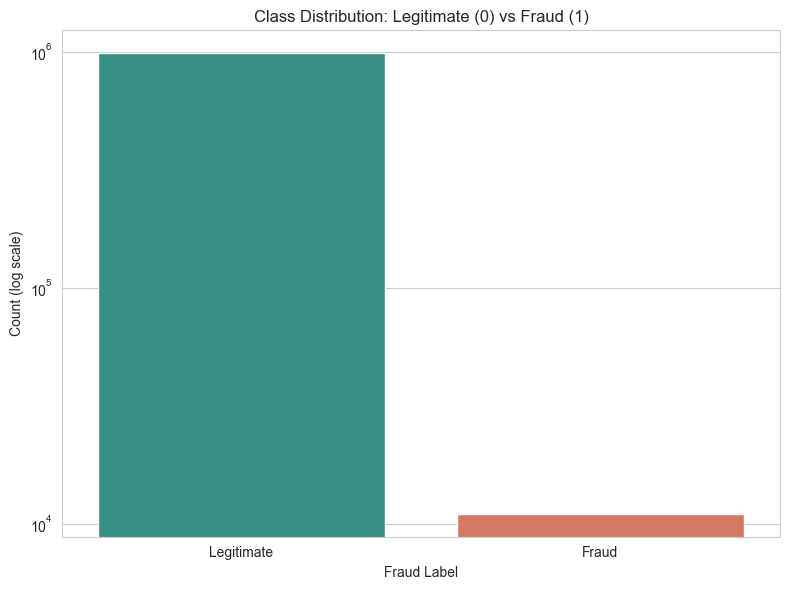

In [31]:
# Count plot of the two classes
plt.figure(figsize=(8, 6))
sns.countplot(x='fraud_bool', data=df, palette=['#2a9d8f', '#e76f51'])

# Log scale on the y-axis, or the fraud bar is too small to see
plt.yscale('log')
plt.title('Class Distribution: Legitimate (0) vs Fraud (1)')
plt.xlabel('Fraud Label')
plt.ylabel('Count (log scale)')
plt.xticks([0, 1], ['Legitimate', 'Fraud'])
plt.tight_layout()
plt.show()

### Key Takeaway

The dataset is severely imbalanced: **11,029 fraudulent applications (1.10%)** against **988,971 legitimate ones (98.90%)** — a class ratio of roughly **90 : 1**. Even on a logarithmic axis the fraud class barely registers.

This single fact drives every downstream decision:

- **Accuracy is discarded** as a metric. A model predicting "legitimate" for everyone scores 98.9% accuracy while catching zero fraud. We evaluate on **PR-AUC, ROC-AUC, precision and recall** instead.
- **Resampling or class weighting** is required so the model actually learns the minority class rather than ignoring it.
- **The decision threshold** will not stay at the default 0.5 — it's tuned on business cost (a missed fraud vs a wrongly rejected genuine customer) in a later notebook.

---

## Section 5 — The Hidden Missing Values (`-1` Sentinels)

Section 3.5 reported **zero** missing values via `isnull()` — but that was misleading. BAF encodes missing values as **`-1`** rather than leaving cells blank, so standard null checks slide right past them. The first clue appeared back in Section 3.4, where `describe()` showed some columns with a minimum of `-1`.

This section uncovers the true extent of missingness. It matters for two reasons:

1. **Data quality** — some columns are almost entirely `-1` and cannot be treated as normal numbers.
2. **Fraud signal** — in fraud problems, *whether* a field is missing can itself be predictive. Fraudulent applications may leave certain fields blank in patterns that differ from genuine ones. We therefore treat missingness as information, not just something to scrub away.

### 5.1 Count `-1` Values Per Column

Scan every column for `-1` and report only the affected ones, sorted by severity. This is the check that exposes what `isnull()` in Section 3.5 missed.

In [32]:
# Compare every value to -1, then sum per column (True counts as 1)
neg_one_counts = (df == -1).sum()

# Keep only columns that actually contain -1, sorted worst-first
neg_one_counts = neg_one_counts[neg_one_counts > 0].sort_values(ascending=False)

print("Columns containing -1 (hidden missing values):\n")
print(neg_one_counts)

Columns containing -1 (hidden missing values):

prev_address_months_count       712920
bank_months_count               253635
current_address_months_count      4254
session_length_in_minutes         2015
credit_risk_score                  488
device_distinct_emails_8w          359
dtype: int64


### 5.2 Missing Percentage Per Column

Raw counts are hard to judge alone — 4,000 missing means very different things in a thousand-row table versus a million-row one. Here we express each as a percentage of the full dataset and show counts and percentages side by side.

In [33]:
# Convert the -1 counts into a percentage of the total number of rows
neg_one_pct = (neg_one_counts / len(df) * 100).round(2)

# Present counts and percentages side by side in a small summary table
missing_summary = pd.DataFrame({
    'missing_count': neg_one_counts,
    'missing_pct': neg_one_pct
})
print(missing_summary)

                              missing_count  missing_pct
prev_address_months_count            712920        71.29
bank_months_count                    253635        25.36
current_address_months_count           4254         0.43
session_length_in_minutes              2015         0.20
credit_risk_score                       488         0.05
device_distinct_emails_8w               359         0.04


### 5.3 Missingness Strategy

Based on the percentages, each affected column falls into one of three buckets. We record the plan here and execute it in the preprocessing notebook — **no changes to the data yet.**

| Column | Missing % | Planned treatment |
|--------|-----------|-------------------|
| `prev_address_months_count` | ~71% | Too sparse to impute — convert to a binary "missing" flag; likely drop the numeric column |
| `bank_months_count` | ~25% | Add a "missing" flag, then impute the remaining values |
| `current_address_months_count` | ~0.4% | Add a flag; impute |
| `session_length_in_minutes` | ~0.2% | Impute (median) |
| `credit_risk_score` | ~0.05% | Impute (median) |
| `device_distinct_emails_8w` | ~0.04% | Impute (median) |

**Guiding principle:** create "is-missing" flags *before* imputing, so the model can learn from the absence of a value — a potential fraud signal — rather than having it silently filled in.

---

## Section 6 — Feature Groups

Before modelling, we sort the columns into groups that will be treated differently in preprocessing: **numeric** features, **categorical** (text) features that need encoding, and the three **protected attributes** reserved for the fairness audit. Separating them now makes the preprocessing notebook cleaner.

### 6.1 Identify Column Types

`select_dtypes` splits columns by data type. Object-type columns are text and will need encoding; the rest are numeric.

In [34]:
# Categorical columns are stored as 'object' (text) type
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Everything else is numeric (int or float)
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Categorical columns:", categorical_cols)
print("\nNumber of categorical columns:", len(categorical_cols))
print("Number of numeric columns:", len(numeric_cols))

Categorical columns: ['payment_type', 'employment_status', 'housing_status', 'source', 'device_os']

Number of categorical columns: 5
Number of numeric columns: 27


### 6.2 The Five Categorical Features

These will need encoding before modelling (one-hot or similar), since models require numeric input:

| Column | What it represents |
|--------|--------------------|
| `payment_type` | Type of payment method on the application |
| `employment_status` | Applicant's employment category |
| `housing_status` | Applicant's housing situation |
| `source` | Channel the application came through |
| `device_os` | Operating system of the device used |

All five are low-cardinality (a handful of categories each), so one-hot encoding is appropriate and won't explode the feature count.

### 6.3 Protected Attributes for the Fairness Audit

A defining feature of the BAF dataset is that it's built for **fair machine learning** research. Three attributes are treated as *protected* — the model's error rates will later be checked across these groups to ensure it isn't systematically harsher on any of them:

| Attribute | Type | Fairness concern |
|-----------|------|------------------|
| `customer_age` | Numeric (binned into groups) | Does the model reject older or younger applicants unfairly? |
| `employment_status` | Categorical | Are certain employment types disproportionately flagged? |
| `income` | Numeric | Does the model penalise lower-income applicants? |

We do **not** drop these — they may be legitimately predictive. Instead, in a later notebook we measure whether the model's mistakes fall unevenly across these groups. This is exactly the responsible-AI check a regulated bank must perform before deploying a model.

### 6.4 Inspect the Protected Attributes

Before relying on these three attributes in a fairness audit, we check how each is actually structured — its range, scale, and group sizes. This confirms what the fairness analysis will be working with and flags any groups too small to draw reliable conclusions from.

In [35]:
# Quick look at the protected attributes so we understand their structure
# before the fairness audit in a later notebook

# customer_age - check the range and distribution
print("customer_age summary:")
print(df['customer_age'].describe())

# employment_status - see the categories and their counts
print("\nemployment_status value counts:")
print(df['employment_status'].value_counts())

# income - check the range
print("\nincome summary:")
print(df['income'].describe())

customer_age summary:
count    1000000.000000
mean          33.689080
std           12.025799
min           10.000000
25%           20.000000
50%           30.000000
75%           40.000000
max           90.000000
Name: customer_age, dtype: float64

employment_status value counts:
employment_status
CA    730252
CB    138288
CF     44034
CC     37758
CD     26522
CE     22693
CG       453
Name: count, dtype: int64

income summary:
count    1000000.000000
mean           0.562696
std            0.290343
min            0.100000
25%            0.300000
50%            0.600000
75%            0.800000
max            0.900000
Name: income, dtype: float64


**What this tells us:**

- `customer_age` is pre-binned into decade bands (10–90), so age groups are already defined for the fairness audit.
- `employment_status` is dominated by one category (`CA` ≈ 73%), and `CG` is tiny (453 people) — fairness estimates for the smallest groups will be noisy and need caveating.
- `income` is normalised to a 0–1 scale (a relative percentile, not dollars), so no further scaling is needed for this column.

---

## Section 7 — Key Observations & Next Steps

### What we learned

1. **Scale** — ~1,000,000 applications across 32 columns (27 numeric, 5 categorical), with no duplicate rows.

2. **Severe class imbalance** — fraud is just **1.10%** of records (11,029 fraud vs 988,971 legitimate), a ~90:1 ratio. This is the defining challenge of the project and rules out accuracy as a metric.

3. **Hidden missing values** — `isnull()` reported nothing, but `-1` sentinels conceal real missingness. Two columns are badly affected — `prev_address_months_count` (71.29%) and `bank_months_count` (25.36%) — while four others are minor (<0.5%).

4. **Protected attributes identified** — `customer_age` (pre-binned decades), `employment_status` (codes CA–CG, dominated by CA), and `income` (0–1 scaled) are reserved for a fairness audit.

### Next steps → Notebook 2: Preprocessing

- Create **"is-missing" flags** for the `-1` columns *before* imputing, so absence itself can act as a fraud signal
- **Drop or flag** `prev_address_months_count` — too sparse (71%) to impute reliably
- **Impute** the remaining `-1` columns (median for the minor ones)
- **One-hot encode** the 5 categorical features
- **Split into train/test _before_ any resampling** — to prevent data leakage
- Prepare the imbalance strategy (SMOTE vs class weights) for the modelling notebook